In [ ]:
from abc import ABC, abstractmethod
from typing import Self


class GraphSearch(ABC):

    def __init__(self, node, goal):
        self.node = node
        self._goal = goal

    def __repr__(self):
        return str(self.node)

    @abstractmethod
    def adj(self) -> list[Self]:
        pass

    @abstractmethod
    def goal(self) -> bool:
        pass

    # ---------------- DFS ----------------

    def dfs(self, path=None, cnt=50) -> list[Self]:
        if cnt is None:
            raise ValueError("DFS braucht eine Tiefenschranke (cnt)!")

        if path is None:
            path = [self]

        if self.goal():
            return path

        if cnt == 0:
            return []

        for n in self.adj():
            if n not in path:
                result = n.dfs(path + [n], cnt - 1)
                if result:
                    return result

        return []

    # ---------------- IDDFS ----------------

    def iddfs(self):
        cur_depth = 0

        while True:
            result = self.dfs(cnt=cur_depth)
            if result:
                return result
            cur_depth += 1

    # ---------------- BFS ----------------

    def bfs(self) -> list[Self]:
        queue = [self]
        visited = {self}
        prev = {self: None}
        i = 0

        while i < len(queue):
            current = queue[i]
            i += 1

            if current.goal():
                path = []
                node = current
                while node is not None:
                    path.append(node)
                    node = prev[node]
                return path[::-1]

            for neighbor in current.adj():
                if neighbor not in visited:
                    visited.add(neighbor)
                    prev[neighbor] = current
                    queue.append(neighbor)

        return []

    # ---------------- IDA* ----------------
    # f = g+h <= f_max
    @abstractmethod
    def h(self) -> int:
        pass

    def ida_star(self):
        f_max = self.h()  # Startwert          , schranke entspricht dem akutellem max Wert von f

        while True:
         result = self.ida_dfs(path=[self], g=0, f_max=f_max)     # Aktueller_knoten,Tiefe,Schranke

         if isinstance(result, list):                   # Liste wurde gefunden --> gibt Pfad zu Ziel zurück
          return result  # Lösung gefunden

         if result == float("inf"):                     # float inf wird zurückgegeben wenn keine pfade mehr verfügbar sind
          return []                                     # keine Lösung gefunden wird

         f_max += 1                                     # Aufgabenstellung

    def ida_dfs(self, path, g, f_max):
        #node = path[-1]
        #f = g + node.h()

        f = g + self.h()

        if f > f_max:               # f wird zurückgegeben bis f_max kleiner als f ist
            return f

        if self.goal():
            return path

        next_f_max = float("inf")

        for n in self.adj():
            if n not in path:
                result = n.ida_dfs(path + [n], g + 1, f_max)

                if isinstance(result, list):
                    return result

                if result < next_f_max:
                    next_f_max = result

        return next_f_max

    # ---------------- helper ----------------

    @staticmethod
    def path_to_str(path: list[Self]) -> str:
        return "\n".join(str(p) for p in path)

In [ ]:
class Graph(GraphSearch):
    adj_list = {0: [1,2,3], 1: [2], 2: [3], 3: [4], 4: [0]}

    def __init__(self, start=0, goal=4):
        super().__init__(start, goal)

    def __repr__(self):
        return str(self.node)

    def adj(self):
        return [Graph(n, self._goal) for n in self.adj_list[self.node]]

    def goal(self) -> bool:
        return self.node == self._goal

    def __eq__(self, other):
        return isinstance(other, Graph) and self.node == other.node

    def __hash__(self):
        return hash(self.node)

s = Graph()
print("BFS:")
print(GraphSearch.path_to_str(s.bfs()))
print("DFS:")
print(GraphSearch.path_to_str(s.dfs()))

BFS:
0
3
4
DFS:
0
1
2
3
4


In [ ]:
# für Aufgabe 5
class Graph(GraphSearch):
    adj_list = {
    #    Zeile,Spalte
    #    (x,y): [(x,y),(x,y),(x,y),(x,y)],
         (0,0): [(0,1)                  ],
         (0,1): [(0,0),(0,2),(1,1)      ],
         (0,2): [(0,1),(0,3)            ],
         (0,3): [(0,2)                  ],
         (0,4): [(1,4)                  ],
         (1,0): [(2,0)                  ],
         (1,1): [(0,1),(1,2),(2,1)      ],
         (1,2): [(1,1)                  ],
         (1,3): [(1,4),(2,3)            ],
         (1,4): [(0,4),(1,3)            ],
         (2,0): [(1,0),(2,1),(3,0)      ],
         (2,1): [(1,1),(2,0)            ],
         (2,2): [(2,3),(3,2)            ],
         (2,3): [(1,3),(2,2),(3,3)      ],
         (2,4): [(3,4)                  ],
         (3,0): [(2,0),(3,1),(4,0)      ],
         (3,1): [(3,0),(4,1)            ],
         (3,2): [(2,2),(4,2)            ],
         (3,3): [(2,3),(3,4)            ],
         (3,4): [(2,4),(3,3),(4,4)      ],
         (4,0): [(3,0)                  ],
         (4,1): [(3,1),(4,2)            ],
         (4,2): [(3,2),(4,1),(4,3)],
         (4,3): [(4,2),(4,4)],
         (4,4): [(3,4),(4,3)]
         }

    def __init__(self, start=(0,0), goal=(0,4)):
        super().__init__(start, goal)

    def __repr__(self):
        return str(self.node)

    def adj(self):
        return [Graph(n, self._goal) for n in self.adj_list[self.node]]

    def goal(self) -> bool:
        return self.node == self._goal

    def __eq__(self, other):
        return isinstance(other, Graph) and self.node == other.node

    def __hash__(self):
        return hash(self.node)

s = Graph()
print("BFS:")
print(GraphSearch.path_to_str(s.bfs()))
print("DFS:")
print(GraphSearch.path_to_str(s.dfs()))

BFS:
(0, 0)
(0, 1)
(1, 1)
(2, 1)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(1, 3)
(1, 4)
(0, 4)
DFS:
(0, 0)
(0, 1)
(1, 1)
(2, 1)
(2, 0)
(3, 0)
(3, 1)
(4, 1)
(4, 2)
(3, 2)
(2, 2)
(2, 3)
(1, 3)
(1, 4)
(0, 4)


In [ ]:
class affe_banane(GraphSearch):
  #affe_pos,stuhl_pos,affe_steht_auf_stuhl?,affe_hat_banane?

    def __init__(self, start=("tür","fenster",False,False), goal=("mitte","mitte",True,True)):
        super().__init__(start, goal)

    def __repr__(self):
        return str(self.node)

    def adj(self):
        affe_pos,stuhl_pos,auf_stuhl, hat_banane = self.node
        pos = ["tür", "mitte", "fenster"]
        neighbors = []

        # 1. Affe bewegt sich
        if not auf_stuhl:
            for p in pos:
                if p != affe_pos:
                    neighbors.append(affe_banane((p, stuhl_pos, False, hat_banane), self._goal))

        # 2. Affe schiebt stuhl
        if not auf_stuhl and affe_pos==stuhl_pos:
          for p in pos:
                if p != affe_pos:
                    neighbors.append(affe_banane((p, p, False,hat_banane), self._goal))

         # 3.Auf Stuhl steigen
        if affe_pos == stuhl_pos and not auf_stuhl:
            neighbors.append(affe_banane((affe_pos, stuhl_pos, True, hat_banane), self._goal))

         # 4. Banane greifen wenn beides in der mitte und affe auf stuhl
        if affe_pos == "mitte" and stuhl_pos == "mitte" and auf_stuhl:
            neighbors.append(affe_banane((affe_pos, stuhl_pos, True, True), self._goal))
        return neighbors





    def goal(self) -> bool:
        return self.node == self._goal

    def __eq__(self, other):
        return isinstance(other, affe_banane) and self.node == other.node

    def __hash__(self):
        return hash(self.node)

s = affe_banane()
print("BFS:")
print("Affe, Stuhl, auf_stuhl?, hat_banane?")
print(GraphSearch.path_to_str(s.bfs()))

print("DFS:")
print(GraphSearch.path_to_str(s.dfs()))

print("DFS mit Tiefenschranke:")
print(GraphSearch.path_to_str(s.iddfs()))

BFS:
Affe, Stuhl, auf_stuhl?, hat_banane?
('tür', 'fenster', False, False)
('fenster', 'fenster', False, False)
('mitte', 'mitte', False, False)
('mitte', 'mitte', True, False)
('mitte', 'mitte', True, True)
DFS:
('tür', 'fenster', False, False)
('mitte', 'fenster', False, False)
('fenster', 'fenster', False, False)
('tür', 'tür', False, False)
('mitte', 'mitte', False, False)
('mitte', 'mitte', True, False)
('mitte', 'mitte', True, True)
DFS mit Tiefenschranke:
('tür', 'fenster', False, False)
('fenster', 'fenster', False, False)
('mitte', 'mitte', False, False)
('mitte', 'mitte', True, False)
('mitte', 'mitte', True, True)


In [ ]:
class missionar_kannibale(GraphSearch):
  #m_left,k_left,boat_pos

    def __init__(self, start=(3,3,"left"), goal=(0,0,"right")):
        super().__init__(start, goal)

    def __repr__(self):
        return str(self.node)

    def adj(self):
        m_left,k_left,boat_pos = self.node
        moves = [
                  (1,0),  # 1 Missionar
                  (2,0),
                  (0,1),  # 1 Kannibale
                  (0,2),
                  (1,1)   # 1 + 1
                ]
        neighbors = []

        for (dm, dk) in moves:
          if boat_pos == "left":
            neuer_zustand = (m_left-dm,k_left-dk,"right")
          else:
            neuer_zustand = (m_left+dm,k_left+dk,"left")

          m, k, state = neuer_zustand

          # 3 Missionare 3 Kannibalen - Grenze einhalten
          if not (0 <= m <= 3 and 0 <= k <= 3):
            continue                 # continue springt an Schleifenkopf und führt nächste Iteration aus

          # rechts berechnen
          m_right = 3 - m
          k_right = 3 - k

          # linke Seite Abbruch bdg.
          if (m > 0 and m < k):
            continue
          # rechte Seite Abbruch bdg.
          if (m_right > 0 and m_right < k_right):
            continue

          neighbors.append(missionar_kannibale(neuer_zustand, self._goal))
        return neighbors

    def goal(self) -> bool:
        return self.node == self._goal

    def __eq__(self, other):
        return isinstance(other,missionar_kannibale) and self.node == other.node

    def __hash__(self):
        return hash(self.node)

s = missionar_kannibale()
#print("BFS:")
#print("M_left,K_left,Boat_Pos")
#print(GraphSearch.path_to_str(s.bfs()))
print("DFS-Iterativ:")
print("M_left,K_left,Boat_Pos")
print(GraphSearch.path_to_str(s.iddfs()))

DFS-Iterativ:
M_left,K_left,Boat_Pos
(3, 3, 'left')
(3, 1, 'right')
(3, 2, 'left')
(3, 0, 'right')
(3, 1, 'left')
(1, 1, 'right')
(2, 2, 'left')
(0, 2, 'right')
(0, 3, 'left')
(0, 1, 'right')
(1, 1, 'left')
(0, 0, 'right')


In [ ]:
class ziege_kohl_wolf(GraphSearch):
  #ziege_pos,kohl_pos,wolf_pos,boot_pos

    def __init__(self, start=("left","left","left","left"), goal=("right","right","right","right")):
        super().__init__(start, goal)

    def __repr__(self):
        return str(self.node)

    def adj(self):
      ziege_pos, kohl_pos, wolf_pos, boot_pos = self.node
      neighbors = []

      items=["ziege","kohl","wolf","boot"]

      for i in items:
          new_boot_pos = "right" if boot_pos == "left" else "left"
          new_ziege_pos, new_kohl_pos, new_wolf_pos = ziege_pos,kohl_pos,wolf_pos

          if i == "ziege" and ziege_pos != boot_pos:
              continue
          if i == "kohl" and kohl_pos != boot_pos:
              continue
          if i == "wolf" and wolf_pos != boot_pos:
              continue

          if i == "ziege":
                new_ziege_pos = new_boot_pos
          elif i == "kohl":
                new_kohl_pos = new_boot_pos
          elif i == "wolf":
                new_wolf_pos = new_boot_pos


          new_state = (new_ziege_pos, new_kohl_pos, new_wolf_pos, new_boot_pos)
          z, k, w, b = new_state

          if (z == k and z != b) or (z == w and z != b):
              continue

          neighbors.append(ziege_kohl_wolf(new_state, self._goal))
      return neighbors


    def goal(self) -> bool:
        return self.node == self._goal

    def __eq__(self, other):
        return isinstance(other,ziege_kohl_wolf) and self.node == other.node

    def __hash__(self):
        return hash(self.node)

s = ziege_kohl_wolf()
#print("BFS:")
#print("ziege_pos,kohl_pos,wolf_pos,boot_pos")
#print(GraphSearch.path_to_str(s.bfs()))
print("DFS-Iterativ:")
print("ziege_pos,kohl_pos,wolf_pos,boot_pos")
print(GraphSearch.path_to_str(s.iddfs()))

DFS-Iterativ:
ziege_pos,kohl_pos,wolf_pos,boot_pos
('left', 'left', 'left', 'left')
('right', 'left', 'left', 'right')
('right', 'left', 'left', 'left')
('right', 'right', 'left', 'right')
('left', 'right', 'left', 'left')
('left', 'right', 'right', 'right')
('left', 'right', 'right', 'left')
('right', 'right', 'right', 'right')


In [ ]:
# Aufgabe 8 = f(n) = g(n) + h(n)
# g(n) = verstrichene Zeit bzw. Tatsächlichezeit
# h(n) = Luftlinie / Höchstgeschwindigkeit im Netzwerk

In [ ]:
""" 15-Verschiebepuzzle """
from secrets import choice
from typing import Self, Tuple
import copy

class Puzzle_hamming(GraphSearch):

#-----------------------h------------------------- r = row , c = column
#    0  1  2  3
#  0[01 02 03 04]
#  1[05 06 07 08]
#  2[09 10 11 12]
#  3[13 14 15 16]

    def h(self) -> int:                            # geht von oben links nach unten rechts und schaut wie viele plättchen falsch platziert sind
      count = 0
      for r in range(4):
        for c in range(4):
          val = self.board[r][c]
          if val != 0:
            goal_val = r * 4 + c + 1
            if val != goal_val:
              count += 1
      return count
 #-------------------------------------------------


    Dir = Tuple[int, int]
    """Bewegungrichtung der Leerstelle als Vektor der Form (row, col). Ursprung links oben."""
    UP: Dir = (-1,0)
    DOWN: Dir = (1,0)
    LEFT: Dir = (0,-1)
    RIGHT: Dir = (0,1)

    DIRECTIONS: list[Dir] = [UP,DOWN,LEFT,RIGHT]

    GOAL_BOARD = [[1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,0]] # 0: Leerstelle
    GOAL_BLANK = (3, 3) # links oben ist (0,0)

    def __init__(self, board = GOAL_BOARD, blank_pos = GOAL_BLANK):
        self.board = board
        self.blank_pos = blank_pos

    def __repr__(self) -> str:
        def to_str(n):
            return ' ' if n == 0 else str(n).rjust(2)
        out_str = ''
        for r in self.board:
            out_str += '\t'.join(map(to_str,r)) + '\n'
        return out_str

    def __eq__(self, other):
        if not isinstance(other, Puzzle_hamming):
            return False
        else:
            return self.blank_pos == other.blank_pos and self.board == other.board

    def __move_blank(self, d: Dir) -> Tuple[int, int, int, int]:
        """Alte und neue Position der Leerstelle, nachdem Bewegung d ausgeführt wurde."""
        r, c = self.blank_pos
        return r, c, r + d[0], c + d[1]

    def moves(self) -> list[Dir]:
        """Liefert alle zulässigen Bewegungen der Leerstelle."""
        def is_valid(d: Puzzle_hamming.Dir) -> bool:
            _, _, r, c = self.__move_blank(d)
            return 0 <= r <= 3 and 0 <= c <= 3
        return [d for d in self.DIRECTIONS if is_valid(d)]

    def move(self, d: Dir) -> Self:
        """Verschiebt Plättchen und liefert neues Brett."""
        b = copy.deepcopy(self.board)
        r1, c1, r2, c2 = self.__move_blank(d)
        b[r1][c1] = b[r2][c2]
        b[r2][c2] = 0
        return Puzzle_hamming(b, (r2, c2))

    def shuffle(self, n: int) -> Self:
        if n == 0:
            return self
        else:
            return self.move(choice(self.moves())).shuffle(n-1)

    def adj(self) -> list[Self]:
        """Adjazenz der aktuellen Brettstellung."""
        return [self.move(d) for d in self.moves()]

    def goal(self) -> bool:
        return self.blank_pos == self.GOAL_BLANK and self.board == self.GOAL_BOARD

def main():
    pz = Puzzle_hamming().shuffle(40)
    path = pz.ida_star()
    print(pz.path_to_str(path))


if __name__ == '__main__':
    main()



 2	 5	 3	 4
 1	 	 7	12
 9	 6	 8	11
13	10	14	15

 2	 	 3	 4
 1	 5	 7	12
 9	 6	 8	11
13	10	14	15

 	 2	 3	 4
 1	 5	 7	12
 9	 6	 8	11
13	10	14	15

 1	 2	 3	 4
 	 5	 7	12
 9	 6	 8	11
13	10	14	15

 1	 2	 3	 4
 5	 	 7	12
 9	 6	 8	11
13	10	14	15

 1	 2	 3	 4
 5	 7	 	12
 9	 6	 8	11
13	10	14	15

 1	 2	 3	 4
 5	 7	 8	12
 9	 6	 	11
13	10	14	15

 1	 2	 3	 4
 5	 7	 8	12
 9	 6	11	 
13	10	14	15

 1	 2	 3	 4
 5	 7	 8	 
 9	 6	11	12
13	10	14	15

 1	 2	 3	 4
 5	 7	 	 8
 9	 6	11	12
13	10	14	15

 1	 2	 3	 4
 5	 	 7	 8
 9	 6	11	12
13	10	14	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	 	11	12
13	10	14	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	11	12
13	 	14	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	11	12
13	14	 	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	11	12
13	14	15	 



In [ ]:
""" 15-Verschiebepuzzle """
from secrets import choice
from typing import Self, Tuple
import copy

class Puzzle_manhattan(GraphSearch):

#-----------------------h------------------------- r = row , c = column
#    0  1  2  3
#  0[01 02 03 04]
#  1[05 06 07 08]
#  2[09 10 11 12]
#  3[13 14 15 16]


    def h(self) -> int:
     dist = 0

     for r in range(4):
        for c in range(4):
            val = self.board[r][c] # speichert den akutellen wert der Stelle r,c

            if val != 0:  # Leerstelle ignorieren
                goal_r = (val - 1) // 4                   # bsp für 8: 7 //4 = 1
                goal_c = (val - 1) % 4                    # bsp für 8: 7 % 4 = 3

                dist += abs(r - goal_r) + abs(c - goal_c) # dist = differnz row + column

     return dist
 #-------------------------------------------------


    Dir = Tuple[int, int]
    """Bewegungrichtung der Leerstelle als Vektor der Form (row, col). Ursprung links oben."""
    UP: Dir = (-1,0)
    DOWN: Dir = (1,0)
    LEFT: Dir = (0,-1)
    RIGHT: Dir = (0,1)

    DIRECTIONS: list[Dir] = [UP,DOWN,LEFT,RIGHT]

    GOAL_BOARD = [[1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,0]] # 0: Leerstelle
    GOAL_BLANK = (3, 3) # links oben ist (0,0)

    def __init__(self, board = GOAL_BOARD, blank_pos = GOAL_BLANK):
        self.board = board
        self.blank_pos = blank_pos

    def __repr__(self) -> str:
        def to_str(n):
            return ' ' if n == 0 else str(n).rjust(2)
        out_str = ''
        for r in self.board:
            out_str += '\t'.join(map(to_str,r)) + '\n'
        return out_str

    def __eq__(self, other):
        if not isinstance(other, Puzzle_manhattan):
            return False
        else:
            return self.blank_pos == other.blank_pos and self.board == other.board

    def __move_blank(self, d: Dir) -> Tuple[int, int, int, int]:
        """Alte und neue Position der Leerstelle, nachdem Bewegung d ausgeführt wurde."""
        r, c = self.blank_pos
        return r, c, r + d[0], c + d[1]

    def moves(self) -> list[Dir]:
        """Liefert alle zulässigen Bewegungen der Leerstelle."""
        def is_valid(d: Puzzle_manhattan.Dir) -> bool:
            _, _, r, c = self.__move_blank(d)
            return 0 <= r <= 3 and 0 <= c <= 3
        return [d for d in self.DIRECTIONS if is_valid(d)]

    def move(self, d: Dir) -> Self:
        """Verschiebt Plättchen und liefert neues Brett."""
        b = copy.deepcopy(self.board)
        r1, c1, r2, c2 = self.__move_blank(d)
        b[r1][c1] = b[r2][c2]
        b[r2][c2] = 0
        return Puzzle_manhattan(b, (r2, c2))

    def shuffle(self, n: int) -> Self:
        if n == 0:
            return self
        else:
            return self.move(choice(self.moves())).shuffle(n-1)

    def adj(self) -> list[Self]:
        """Adjazenz der aktuellen Brettstellung."""
        return [self.move(d) for d in self.moves()]

    def goal(self) -> bool:
        return self.blank_pos == self.GOAL_BLANK and self.board == self.GOAL_BOARD

def main():
    pz = Puzzle_manhattan().shuffle(40)
    path = pz.ida_star()
    print(pz.path_to_str(path))


if __name__ == '__main__':
    main()



 1	 2	 3	 4
 5	10	 6	 
 9	12	 8	 7
13	14	11	15

 1	 2	 3	 4
 5	10	 6	 7
 9	12	 8	 
13	14	11	15

 1	 2	 3	 4
 5	10	 6	 7
 9	12	 	 8
13	14	11	15

 1	 2	 3	 4
 5	10	 6	 7
 9	 	12	 8
13	14	11	15

 1	 2	 3	 4
 5	 	 6	 7
 9	10	12	 8
13	14	11	15

 1	 2	 3	 4
 5	 6	 	 7
 9	10	12	 8
13	14	11	15

 1	 2	 3	 4
 5	 6	 7	 
 9	10	12	 8
13	14	11	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	12	 
13	14	11	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	 	12
13	14	11	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	11	12
13	14	 	15

 1	 2	 3	 4
 5	 6	 7	 8
 9	10	11	12
13	14	15	 



In [ ]:
import time
import copy
import tracemalloc


def run_test(p1, p2):
    start = time.time()
    path1 = p1.ida_star()
    t1 = time.time() - start

    start = time.time()
    path2 = p2.ida_star()
    t2 = time.time() - start

    print("=== Hamming ===")
    print("Schritte:", len(path1))
    print("Zeit:", t1)

    print("\n=== Manhattan ===")
    print("Schritte:", len(path2))
    print("Zeit:", t2)


# ---------------- Generator mit Counter ----------------

def generate_start(min_steps, max_tries=20):
    for i in range(1, max_tries + 1):

        print(f"\rVersuch {i}/{max_tries}", end="")

        base = Puzzle_hamming().shuffle(40)

        p1 = Puzzle_hamming(base.board, base.blank_pos)
        p2 = Puzzle_manhattan(base.board, base.blank_pos)

        test = p1.ida_star()

        if test and len(test) >= min_steps:
            print(f"\n✔ Gefunden nach {i} Versuchen (Länge: {len(test)})")
            return p1, p2

    print("\n❌ Kein passendes Puzzle gefunden")
    raise Exception("Abbruch")


# ---------------- Main ----------------

def main():
    p1, p2 = generate_start(min_steps=25)

    run_test(p1, p2)


if __name__ == "__main__":
    main()

Versuch 20/20
❌ Kein passendes Puzzle gefunden


Exception: Abbruch

In [ ]:
!pip install ortools

In [ ]:
def Aufgabe_12():
    gerichte = [
    ("Suppe", "Vorspeise", 150),
    ("Salat", "Vorspeise", 100),
    ("Steak", "Hauptspeise", 700),
    ("Pasta", "Hauptspeise", 500),
    ("Eis", "Nachspeise", 300),
    ("Obst", "Nachspeise", 120)]
    cmax = 900

    vorspeisen = [g for g in gerichte if g[1] == "Vorspeise"]
    hauptspeisen = [g for g in gerichte if g[1] == "Hauptspeise"]
    nachspeisen = [g for g in gerichte if g[1] == "Nachspeise"]

    for v in vorspeisen:
        for h in hauptspeisen:
            for n in nachspeisen:
                kcal = v[2] + h[2] + n[2]
                if kcal <= cmax:
                    print("Menü:")
                    print(v[0], h[0], n[0],"kcal:", kcal)





def main():
    print(Aufgabe_12())

if __name__ == '__main__':
    main()



Menü:
Suppe Pasta Obst kcal: 770
Menü:
Salat Pasta Eis kcal: 900
Menü:
Salat Pasta Obst kcal: 720
None


In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 25.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

In [ ]:
from ortools.sat.python import cp_model

def Aufgabe_12():
    model = cp_model.CpModel()

    # Kategorie = "Name" , kcal
    vorspeisen = [("Suppe", 150), ("Salat", 100)]
    hauptspeisen = [("Steak", 700), ("Pasta", 500)]
    nachspeisen = [("Eis", 300), ("Obst", 120)]

    cmax = 1100

    # Index-Variablen
    v = model.NewIntVar(0, len(vorspeisen)-1, "v")
    h = model.NewIntVar(0, len(hauptspeisen)-1, "h")
    n = model.NewIntVar(0, len(nachspeisen)-1, "n")

    # Kalorien berechnen (über Hilfsvariablen)
    #kcal_x = model.NewIntVar(untere Schranke, obere Schranke, variablen Name))
    kcal_v = model.NewIntVar(0, 1000, "kcal_v")
    kcal_h = model.NewIntVar(0, 1000, "kcal_h")
    kcal_n = model.NewIntVar(0, 1000, "kcal_n")

    model.AddElement(v, [k[1] for k in vorspeisen], kcal_v)
    model.AddElement(h, [k[1] for k in hauptspeisen], kcal_h)
    model.AddElement(n, [k[1] for k in nachspeisen], kcal_n)

    # Gesamt kcal

    model.Add(kcal_v + kcal_h + kcal_n <= cmax)

    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status == cp_model.FEASIBLE or status == cp_model.OPTIMAL:
        print("Menü:")
        print(vorspeisen[solver.Value(v)][0])
        print(hauptspeisen[solver.Value(h)][0])
        print(nachspeisen[solver.Value(n)][0])
        print("kcal:", solver.Value(kcal_v + kcal_h + kcal_n))

Aufgabe_12()

Menü:
Salat
Steak
Eis
kcal: 1100


In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 22.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

In [ ]:
from ortools.sat.python import cp_model

def balken_problem():
    model = cp_model.CpModel()

    # Positionen (-10 bis 10, ohne 0)
    x1 = model.NewIntVar(-10, 10, "x1")
    x2 = model.NewIntVar(-10, 10, "x2")
    x3 = model.NewIntVar(-10, 10, "x3")

    # 0 ausschließen
    for x in [x1, x2, x3]:
        model.Add(x != 0)

    # Alle Positionen verschieden
    model.AddAllDifferent([x1, x2, x3])

    # Hebelgesetz
    model.Add(12 * x1 + 30 * x2 + 40 * x3 == 0)

    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print("Lösung:")
        print("12 kg bei:", solver.Value(x1))
        print("30 kg bei:", solver.Value(x2))
        print("40 kg bei:", solver.Value(x3))
    else:
        print("Keine Lösung gefunden")

balken_problem()

Lösung:
12 kg bei: -5
30 kg bei: -10
40 kg bei: 9


In [ ]:
!pip install pandas as pd
!pip install pgmpy

ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 13.8 MB/s eta 0:00:00


In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
import pandas as pd

# Kanten des Netzwerks
alarm_model = DiscreteBayesianNetwork(
    [
        ("Burglary", "Alarm"),
        ("Earthquake", "Alarm"),
        ("Alarm", "JohnCalls"),
        ("Alarm", "MaryCalls"),
    ]
)

"""Erzeugt Liste [Gegenwahrscheinlichkeiten, Wahrscheinlichkeiten]"""
def probs(ps: list[float]) -> list[list[float]]:
    return [[1-p for p in ps], ps]

# Knoten mit Wahrscheinlichkeiten und Gegenwahrscheinlichkeiten
cpd_burglary = TabularCPD(
    "Burglary", 2, values=probs([0.001]) # P(Burglary=1) = 0.001
)
cpd_earthquake = TabularCPD(
    "Earthquake", 2, values=probs([0.002])
)

cpd_alarm = TabularCPD(
    "Alarm",
    2,
    values=probs([0.001, 0.29, 0.94, 0.95]), # p(Alarm=1 | Burglary=0, Earthquake=0) = 0.001
    evidence=["Burglary", "Earthquake"], # Vorgängerknoten
    evidence_card=[2, 2],
)

cpd_johncalls = TabularCPD(
    "JohnCalls",
    2,
    values=probs([0.05, 0.9]),
    evidence=["Alarm"],
    evidence_card=[2],
)
cpd_marycalls = TabularCPD(
    "MaryCalls",
    2,
    values=probs([0.01, 0.7]),
    evidence=["Alarm"],
    evidence_card=[2],
)

alarm_model.add_cpds(
    cpd_burglary, cpd_earthquake, cpd_alarm, cpd_johncalls, cpd_marycalls
)

bg_call = alarm_model.get_state_probability({'Burglary': True, 'JohnCalls': True})
call = alarm_model.get_state_probability({'JohnCalls': True})
print(bg_call / call)

print(alarm_model.predict_probability(pd.DataFrame([{'JohnCalls': 1}])))



0.016283729946769937


/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


   Burglary_0  Burglary_1  Earthquake_0  Earthquake_1   Alarm_0   Alarm_1  \
0    0.983716    0.016284      0.988605      0.011395  0.956562  0.043438   

   MaryCalls_0  MaryCalls_1  
0     0.960028     0.039972  


In [ ]:
cpd_alarm.to_dataframe()

Alarm                    0      1
Burglary Earthquake              
0        0           0.999  0.001
         1           0.710  0.290
1        0           0.060  0.940
         1           0.050  0.950

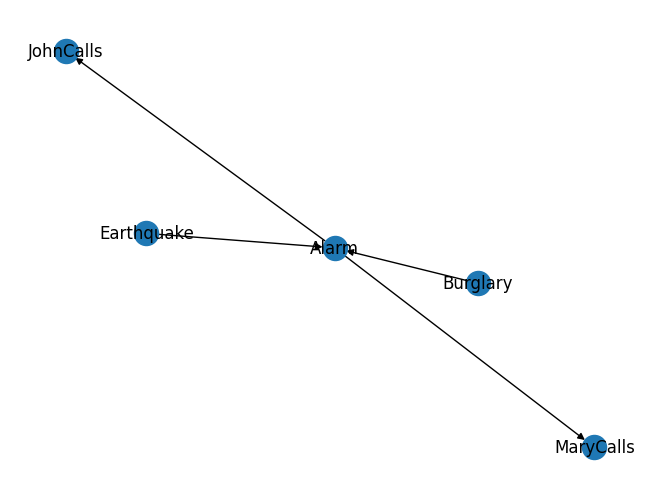

In [ ]:
import networkx as nx
nx_graph = nx.DiGraph(alarm_model.edges())
nx.draw(nx_graph, with_labels=True)

In [ ]:
(alarm_model.get_state_probability({'Burglary':1,'JohnCalls':1,'MaryCalls':1})/
alarm_model.get_state_probability({'JohnCalls':1,'MaryCalls':1}))

np.float64(0.28417183536439294)

In [ ]:
alarm_model.predict_probability(pd.Dataframe([{}]))

In [ ]:
2#Aufgabe 17
# Knoten Bewölkung,Regen,Sprinkler,Gras nass

# P(Bewölkung) = 0.5

# P(Sprinkler | Bewölkung) = 0.1
# p(Sprinkler | nicht Bewölkung) = 0.5

# P(Regen | Bewölkung) = 0.8
# P(Regen | nicht Bewölkung) = 0.2

# P(Gras nass | Regen oder Sprinkler) = 0.9
# P(Gras nass | Regen und Sprinkler) = 1
# P(Gras nass | nicht Sprinker und nicht Regen) = 0


from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
import pandas as pd

# Kanten des Netzwerks
Grasnass_model = DiscreteBayesianNetwork(
    [
        ("Bewölkung", "Sprinkler"),
        ("Bewölkung", "Regen"),
        ("Regen", "Gras_nass"),
        ("Sprinkler", "Gras_nass"),
    ]
)

"""Erzeugt Liste [Gegenwahrscheinlichkeiten, Wahrscheinlichkeiten]"""
def probs(ps: list[float]) -> list[list[float]]:
    return [[1-p for p in ps], ps]

# Knoten mit Wahrscheinlichkeiten und Gegenwahrscheinlichkeiten
cpd_bewölkung = TabularCPD(
    "Bewölkung", 2, values=probs([0.5])
)

cpd_regen = TabularCPD(
    "Regen",
    2,                          # Anzahl Zustände --> 0 False , 1 True
    values=probs([0.2, 0.8]),   # P(Regen  | nicht Bewölkt), P(Regen | Bewölkt) -->
    evidence=["Bewölkung"],     # Vorgänger
    evidence_card=[2],
)

cpd_sprinkler = TabularCPD(
    "Sprinkler",
    2,
    values=probs([0.5, 0.1]),
    evidence=["Bewölkung"],
    evidence_card=[2],
)

cpd_gras_nass = TabularCPD(
    "Gras_nass",
    2,
    values=probs([0.0,0.9,0.9,1.0]),
    evidence=["Regen","Sprinkler"],
    evidence_card=[2,2],          #Anzahl Zustände der evidence Variablen --> 00,01,10,11
)

Grasnass_model.add_cpds(
    cpd_bewölkung, cpd_regen, cpd_sprinkler, cpd_gras_nass
)

#nx_graph = nx.DiGraph(Grasnass_model.edges())
#nx.draw(nx_graph, with_labels=True)

#a)
# P(Gras_nass∣Bewölkt)=
# P(G_n,B)/P(B)
# b)
# P(Bewölkt | Gras_nass)
# P(G_n,B)/P(G_n)
a1 = Grasnass_model.get_state_probability({'Gras_nass': True, 'Bewölkung': True, })
a2 = Grasnass_model.get_state_probability({'Bewölkung': True})
print("P(G_n | Bewölkt):",a1/a2)

b1 = Grasnass_model.get_state_probability({'Gras_nass': True, 'Bewölkung': True, })
b2 = Grasnass_model.get_state_probability({'Gras_nass': True})
print("P(Bewölkt | G_n):",b1/b2)



P(G_n | Bewölkt): 0.7460000000000001
P(Bewölkt | G_n): 0.5756172839506173


In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 20.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 wh

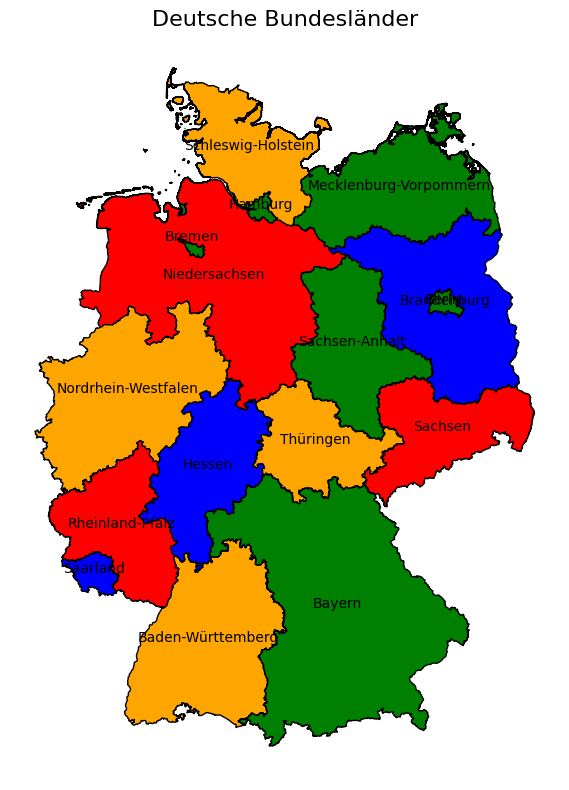

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

gdf = gpd.read_file("germany_states/gadm41_DEU_1.shp").to_crs(3857)

colors=['red','blue','orange','green'] # max 4 Farben
adj = {
    "Schleswig-Holstein": ["Hamburg", "Niedersachsen", "Mecklenburg-Vorpommern"],                                             #1
    "Hamburg": ["Schleswig-Holstein", "Niedersachsen"],                                                                       #2
    "Niedersachsen": ["Schleswig-Holstein","Hamburg","Bremen","Sachsen-Anhalt","Brandenburg","Hessen","Nordrhein-Westfalen","Mecklenburg-Vorpommern"], #3
    "Bremen": ["Niedersachsen"],                                                                                              #4
    "Mecklenburg-Vorpommern": ["Schleswig-Holstein","Brandenburg","Niedersachsen"],                                           #5
    "Brandenburg": ["Mecklenburg-Vorpommern","Berlin","Sachsen-Anhalt","Sachsen"],                                            #6
    "Berlin": ["Brandenburg"],                                                                                                #7
    "Sachsen-Anhalt": ["Niedersachsen","Brandenburg","Sachsen","Thüringen"],                                                  #8
    "Sachsen": ["Brandenburg","Sachsen-Anhalt","Thüringen"],                                                                  #9
    "Thüringen": ["Hessen","Niedersachsen","Sachsen-Anhalt","Sachsen","Bayern"],                                              #10
    "Hessen": ["Nordrhein-Westfalen","Niedersachsen","Thüringen","Bayern","Rheinland-Pfalz"],                                 #11
    "Nordrhein-Westfalen": ["Niedersachsen","Hessen","Rheinland-Pfalz"],                                                      #12
    "Rheinland-Pfalz": ["Nordrhein-Westfalen","Hessen","Saarland","Baden-Württemberg"],                                       #13
    "Saarland": ["Rheinland-Pfalz"],                                                                                          #14
    "Baden-Württemberg": ["Rheinland-Pfalz","Hessen","Bayern",],                                                              #15
    "Bayern": ["Baden-Württemberg","Hessen","Thüringen","Sachsen"]                                                            #16
}

model = cp_model.CpModel()

länder = list(adj.keys()) # Länder werden als normale Liste dargestellt

tmp = {}                  # Liste für Länder mit einer variable für die Farbe
for l in länder:
    tmp[l] = model.NewIntVar(0, 3, l) #tmp[l] = ist 0-3

for u in adj:
    for v in adj[u]:
        model.Add(tmp[u] != tmp[v]) #tmp[land] != tmp(nachbarland)

solver = cp_model.CpSolver()
status = solver.Solve(model)

solution = {}
if status == cp_model.FEASIBLE or cp_model.OPTIMAL:

for l in länder:
  solution[l] = solver.Value(x[l])


gdf["color"] = gdf["NAME_1"].map(lambda x: colors[solution[x]])
fig, ax = plt.subplots(figsize=(8, 8))

gdf.plot(ax=ax, color=gdf["color"], edgecolor="black")

for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, row["NAME_1"], fontsize=10, ha="center")

ax.set_title("Deutsche Bundesländer", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ERROR: unknown command "sklearn.datasets"


In [ ]:
# texte klassifizieren mit dem Naiven Bayesklassifikator  und Scikit
import numpy as np #Array Datentyp
from sklearn.datasets import fetch_20newsgroups # predefinirte Datensätze für


In [ ]:
ng_train = fetch_20newsgroups(subset='train',remove=('headers','footers','quotes'))
ng_test = fetch_20newsgroups(subset='test',remove=('headers','footers','quotes'))

In [ ]:
print(ng_train.data[0], ng_train.target_names[ng_train.target[0]])

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail. rec.autos


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(stop_words='english')       # Stop words werden herausgefiltert, z.B Artikel [wenig relevante Wörter für Klassifizierung]
                                                               # Binary= true --> Zählt nur ob Wort vorkommt oder nicht

In [ ]:
X_train = vec.fit_transform(ng_train.data)        # Erzeugt Vocabular aus Daten ohne Stopwords und Wörter werden durchnumeriert x1...xn -> Überführung in Vektor
X_test = vec.transform(ng_test.data)

In [ ]:
X_train.shape

(11314, 101322)

In [ ]:
vec.transform([ng_train.data[0]]).toarray()       # theorethisch sind eine handvoll Werte 1, das lässt sich schlecht abbilden

array([[0, 0, 0, ..., 0, 0, 0]])

In [ ]:
from sklearn.naive_bayes import MultinomialNB                #Accuraccy
bnb = MultinomialNB(alpha=0.25).fit(X_train, ng_train.target) #alpha --> Stärke der Glättung, bei 1 = Laplace Glättung

In [ ]:
bnb.score(X_test, ng_test.target)

0.6615772703133298

In [ ]:
bnb.predict(X_train[0])[0]

np.int64(7)

In [ ]:
ng_train.target_names[7]

'rec.autos'

In [ ]:
text = "How can i programm a videoplayer via Directx in Windows"
text2 = "Do my taxes get increased when i buy a lot of new guns, to be exactly 2 ak-74s and a glock-18"
text3 = "how many seconds does light need to travel from sun to neptun"
v=vec.transform([text3])
ng_train.target_names[bnb.predict(v)[0]]

'sci.space'

In [ ]:
from sklearn import datasets
digits = datasets.load_digits()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(digits.data,digits.target) #y test / train sind targets bzw. labels
logr = LogisticRegression(solver='newton-cg').fit(X_train,y_train)

In [ ]:
logr.score(X_test, y_test)

0.9622222222222222

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # beides für Darstellung
import pandas as pd # Datenstruktur dataframe
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris # Datensatz über schwert lilien

In [ ]:
iris = load_iris()
x = iris.data
y = iris.target
df = pd.DataFrame(x, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
kmeans = KMeans(n_clusters=3)
labels =kmeans.fit_predict(x)

df['cluster'] = labels

NameError: name 'plot' is not defined

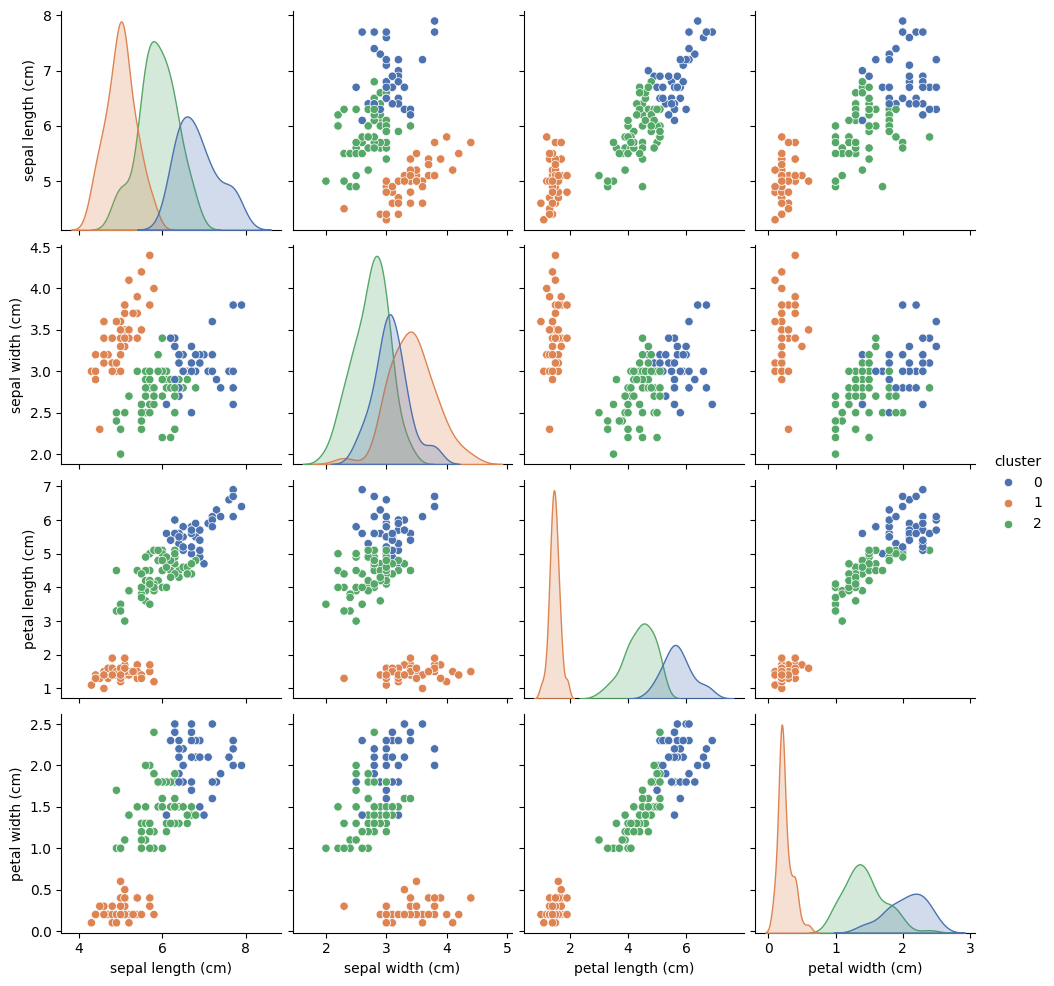

In [ ]:
sns.pairplot(data=df, hue='cluster', palette='deep')
plot.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
cluster_model = AgglomerativeClustering(n_clusters=3,linkage='average') # Hirachisches Cluster entspricht agglomerative clustering
df['cluster'] = cluster_model.fit_predict(x)

In [ ]:
cluster_palette=sns.color_palette("Set1",3)
row_colors = df['cluster'].map(lambda x: cluster_palette[x]) # x -> f(x) entspricht lambda funktion 0,1,2 werden zu verschiedenen farben
features_df = df.drop(columns=['cluster'])

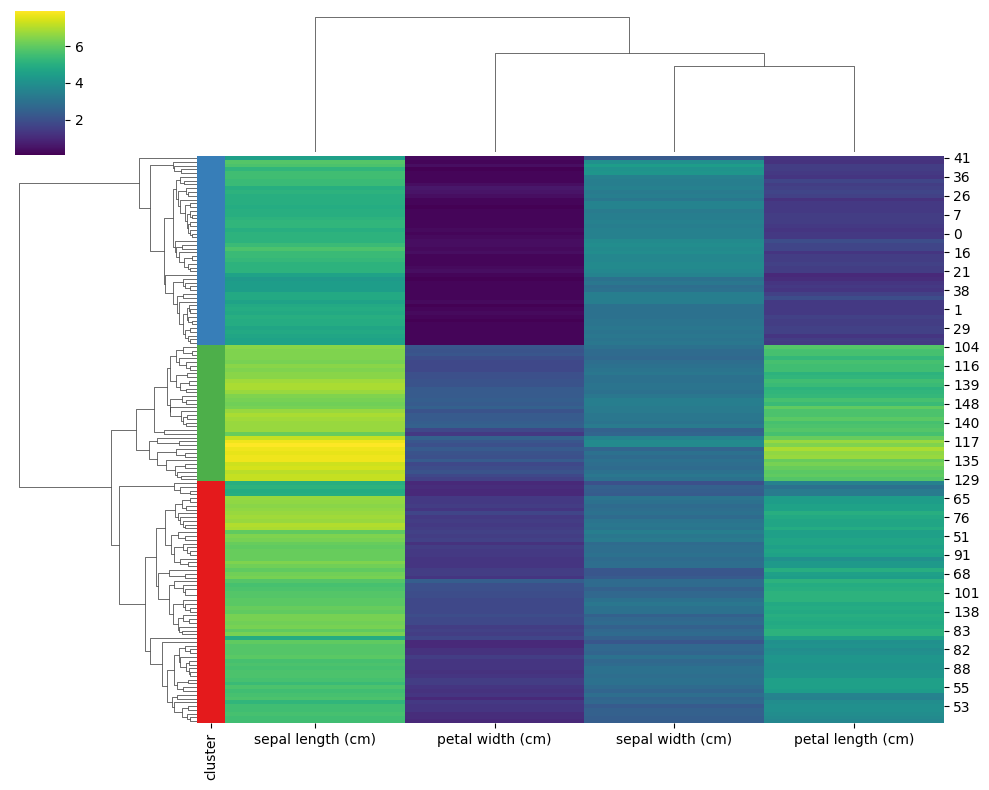

In [ ]:
sns.clustermap(
    features_df,
    method='average',
    metric='euclidean',
    row_colors=row_colors,
    cmap='viridis',
    figsize=(10,8))
plt.show()

In [ ]:
from sklearn import datasets
digits = datasets.load_digits()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(digits.data,digits.target)

knn = KNeighborsClassifier(n_neighbors=1).fit(X_train,y_train) # fit ist methode um model zu erstellen und parameter anpasst

In [ ]:
knn.score(X_test, y_test) # score von 0.99 heißt das etwa jedes 100. Bild falsch erkannt wird

0.9755555555555555

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier()
from sklearn.model_selection import cross_val_score
cross_val_score(dt,x,y)

array([0.96666667, 0.96666667, 0.9       , 0.96666667, 1.        ])

TypeError: can only concatenate str (not "numpy.int64") to str

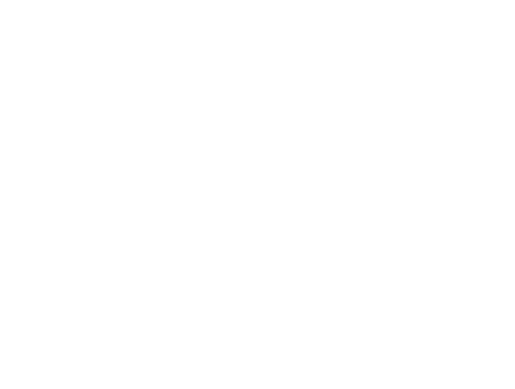

In [ ]:
plot_tree(dt.fit(x,y),feature_names=iris.feature_names, class_names=iris.target) #?? hollas
plt.show()

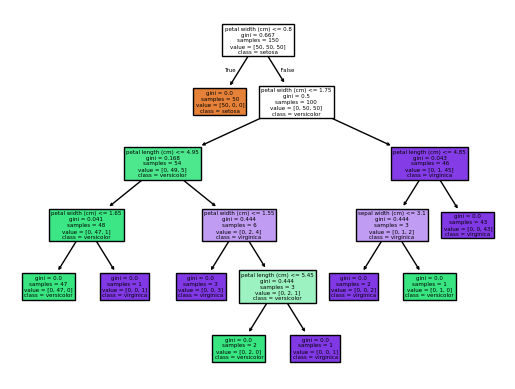

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt.fit(x, y)

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

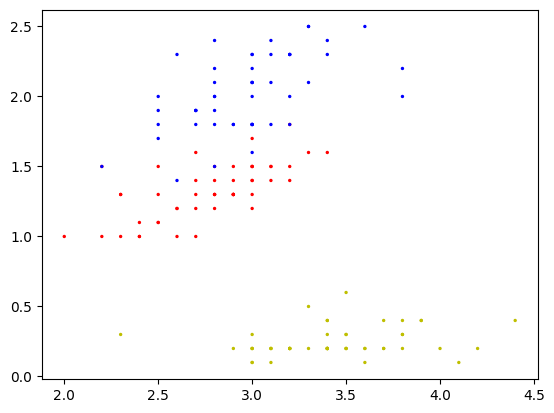

In [ ]:
import numpy as np
cols = np.array(['y','r','b'])
plt.scatter(iris.data[:,1],iris.data[:,3], s=2, c=cols[iris.target])           # : steht für alle Daten in der Dimension
plt.show()